In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Sleep_Efficiency.csv")

In [3]:
df.rename(columns=lambda x: x.replace(" ", "_").lower(), inplace=True)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      452 non-null    int64  
 1   age                     452 non-null    int64  
 2   gender                  452 non-null    object 
 3   bedtime                 452 non-null    object 
 4   wakeup_time             452 non-null    object 
 5   sleep_duration          452 non-null    float64
 6   sleep_efficiency        452 non-null    float64
 7   rem_sleep_percentage    452 non-null    int64  
 8   deep_sleep_percentage   452 non-null    int64  
 9   light_sleep_percentage  452 non-null    int64  
 10  awakenings              432 non-null    float64
 11  caffeine_consumption    427 non-null    float64
 12  alcohol_consumption     438 non-null    float64
 13  smoking_status          452 non-null    object 
 14  exercise_frequency      446 non-null    fl

In [5]:
df.head()

,id,age,gender,bedtime,wakeup_time,sleep_duration,sleep_efficiency,rem_sleep_percentage,deep_sleep_percentage,light_sleep_percentage,awakenings,caffeine_consumption,alcohol_consumption,smoking_status,exercise_frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


Text(0, 0.5, 'Count')

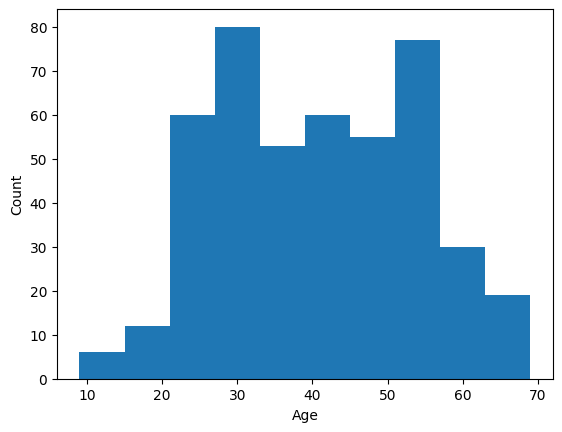

In [7]:
plt.hist(df["age"], 10)
plt.xlabel("Age")
plt.ylabel("Count")

In [9]:
sleep_duration = df["sleep_duration"]

In [10]:
mean_sleep_duration = np.mean(sleep_duration)

In [11]:
df.caffeine_consumption.nlargest(5)

62     200.0
81     200.0
96     200.0
161    200.0
111    100.0
Name: caffeine_consumption, dtype: float64

In [12]:
df.caffeine_consumption.nsmallest(5)

0    0.0
1    0.0
2    0.0
4    0.0
9    0.0
Name: caffeine_consumption, dtype: float64

In [13]:
null_coffeine_consumption_rows = df[df.caffeine_consumption.isna()]
null_coffeine_consumption_rows

,id,age,gender,bedtime,wakeup_time,sleep_duration,sleep_efficiency,rem_sleep_percentage,deep_sleep_percentage,light_sleep_percentage,awakenings,caffeine_consumption,alcohol_consumption,smoking_status,exercise_frequency
5,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
24,25,24,Male,2021-09-16 00:00:00,2021-09-16 07:00:00,7.0,0.88,15,75,10,1.0,NaN,5.0,No,2.0
26,27,36,Female,2021-06-18 00:00:00,2021-06-18 07:00:00,7.0,0.95,28,55,17,0.0,NaN,0.0,No,1.0
37,38,20,Female,2021-09-05 00:00:00,2021-09-05 09:00:00,9.0,0.82,26,56,18,4.0,NaN,0.0,No,1.0
57,58,43,Male,2021-03-20 02:00:00,2021-03-20 09:30:00,7.5,0.91,23,58,19,1.0,NaN,0.0,Yes,3.0
60,61,32,Female,2021-06-11 02:30:00,2021-06-11 10:00:00,7.5,0.95,28,60,12,1.0,NaN,0.0,No,1.0
63,64,35,Female,2021-05-08 21:00:00,2021-05-08 04:30:00,7.5,0.93,28,55,17,1.0,NaN,0.0,No,1.0
64,65,30,Male,2021-04-24 01:30:00,2021-04-24 09:00:00,7.5,0.85,20,70,10,1.0,NaN,0.0,No,3.0
114,115,32,Male,2021-07-02 00:30:00,2021-07-02 09:00:00,8.5,0.89,19,63,18,1.0,NaN,0.0,Yes,1.0
136,137,52,Male,2021-03-05 00:30:00,2021-03-05 07:30:00,7.0,0.90,19,63,18,0.0,NaN,3.0,Yes,1.0


In [14]:
mean_coffeine_consumption = df.caffeine_consumption.mean()
mean_coffeine_consumption

np.float64(23.653395784543324)

In [15]:
df["caffeine_consumption"] = df["caffeine_consumption"].fillna(value=mean_coffeine_consumption)

In [16]:
null_coffeine_consumption_rows

,id,age,gender,bedtime,wakeup_time,sleep_duration,sleep_efficiency,rem_sleep_percentage,deep_sleep_percentage,light_sleep_percentage,awakenings,caffeine_consumption,alcohol_consumption,smoking_status,exercise_frequency
5,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
24,25,24,Male,2021-09-16 00:00:00,2021-09-16 07:00:00,7.0,0.88,15,75,10,1.0,NaN,5.0,No,2.0
26,27,36,Female,2021-06-18 00:00:00,2021-06-18 07:00:00,7.0,0.95,28,55,17,0.0,NaN,0.0,No,1.0
37,38,20,Female,2021-09-05 00:00:00,2021-09-05 09:00:00,9.0,0.82,26,56,18,4.0,NaN,0.0,No,1.0
57,58,43,Male,2021-03-20 02:00:00,2021-03-20 09:30:00,7.5,0.91,23,58,19,1.0,NaN,0.0,Yes,3.0
60,61,32,Female,2021-06-11 02:30:00,2021-06-11 10:00:00,7.5,0.95,28,60,12,1.0,NaN,0.0,No,1.0
63,64,35,Female,2021-05-08 21:00:00,2021-05-08 04:30:00,7.5,0.93,28,55,17,1.0,NaN,0.0,No,1.0
64,65,30,Male,2021-04-24 01:30:00,2021-04-24 09:00:00,7.5,0.85,20,70,10,1.0,NaN,0.0,No,3.0
114,115,32,Male,2021-07-02 00:30:00,2021-07-02 09:00:00,8.5,0.89,19,63,18,1.0,NaN,0.0,Yes,1.0
136,137,52,Male,2021-03-05 00:30:00,2021-03-05 07:30:00,7.0,0.90,19,63,18,0.0,NaN,3.0,Yes,1.0


In [17]:
df.caffeine_consumption.isna().sum()

np.int64(0)

In [18]:
df.awakenings.nsmallest(5)

0     0.0
5     0.0
7     0.0
11    0.0
12    0.0
Name: awakenings, dtype: float64

In [19]:
df.awakenings.nlargest(5)

9     4.0
13    4.0
16    4.0
37    4.0
59    4.0
Name: awakenings, dtype: float64

In [20]:
mean_awakenings = df.awakenings.mean()

In [21]:
df["awakenings"] = df["awakenings"].fillna(value=mean_awakenings)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      452 non-null    int64  
 1   age                     452 non-null    int64  
 2   gender                  452 non-null    object 
 3   bedtime                 452 non-null    object 
 4   wakeup_time             452 non-null    object 
 5   sleep_duration          452 non-null    float64
 6   sleep_efficiency        452 non-null    float64
 7   rem_sleep_percentage    452 non-null    int64  
 8   deep_sleep_percentage   452 non-null    int64  
 9   light_sleep_percentage  452 non-null    int64  
 10  awakenings              452 non-null    float64
 11  caffeine_consumption    452 non-null    float64
 12  alcohol_consumption     438 non-null    float64
 13  smoking_status          452 non-null    object 
 14  exercise_frequency      446 non-null    fl

In [23]:
df.alcohol_consumption.nsmallest(5)

0    0.0
2    0.0
5    0.0
6    0.0
7    0.0
Name: alcohol_consumption, dtype: float64

In [24]:
df.alcohol_consumption.nlargest(5)

3      5.0
24     5.0
49     5.0
77     5.0
103    5.0
Name: alcohol_consumption, dtype: float64

In [25]:
mean_alcohol_consumption = df.alcohol_consumption.mean()
mean_alcohol_consumption

np.float64(1.17351598173516)

In [26]:
df["alcohol_consumption"] = df["alcohol_consumption"].fillna(value=mean_alcohol_consumption)

In [27]:
df.alcohol_consumption.isna()

0      False
1      False
2      False
3      False
4      False
       ...  
447    False
448    False
449    False
450    False
451    False
Name: alcohol_consumption, Length: 452, dtype: bool

In [28]:
df.exercise_frequency.nlargest()

15     5.0
226    5.0
247    5.0
257    5.0
333    5.0
Name: exercise_frequency, dtype: float64

In [29]:
df.exercise_frequency.nsmallest()

9     0.0
14    0.0
16    0.0
18    0.0
31    0.0
Name: exercise_frequency, dtype: float64

In [30]:
mean_exercise_frequency = df.exercise_frequency.mean()
mean_exercise_frequency

np.float64(1.7914798206278026)

In [31]:
df["exercise_frequency"] = df["exercise_frequency"].fillna(value=mean_exercise_frequency)

In [32]:
df.exercise_frequency.isna().any()

np.False_

In [33]:
df.corr(numeric_only=True)

,id,age,sleep_duration,sleep_efficiency,rem_sleep_percentage,deep_sleep_percentage,light_sleep_percentage,awakenings,caffeine_consumption,alcohol_consumption,exercise_frequency
id,1.000000,0.021310,0.014333,-0.025624,0.051636,-0.047300,0.036463,-0.055429,-0.057518,0.113164,0.024416
age,0.021310,1.000000,-0.062462,0.098357,0.042091,0.021730,-0.031905,-0.017468,-0.168273,0.046474,0.071892
sleep_duration,0.014333,-0.062462,1.000000,-0.027467,-0.015940,-0.037304,0.041804,0.004829,-0.014542,-0.045662,-0.067903
sleep_efficiency,-0.025624,0.098357,-0.027467,1.000000,0.062362,0.787335,-0.819204,-0.554498,0.063121,-0.383671,0.257974
rem_sleep_percentage,0.051636,0.042091,-0.015940,0.062362,1.000000,-0.208159,-0.017462,-0.024992,0.058018,-0.051709,0.031165
deep_sleep_percentage,-0.047300,0.021730,-0.037304,0.787335,-0.208159,1.000000,-0.974311,-0.300301,0.001683,-0.355842,0.178281
light_sleep_percentage,0.036463,-0.031905,0.041804,-0.819204,-0.017462,-0.974311,1.000000,0.312734,-0.015079,0.375662,-0.189422
awakenings,-0.055429,-0.017468,0.004829,-0.554498,-0.024992,-0.300301,0.312734,1.000000,-0.103769,0.198491,-0.212485
caffeine_consumption,-0.057518,-0.168273,-0.014542,0.063121,0.058018,0.001683,-0.015079,-0.103769,1.000000,-0.117113,-0.064172
alcohol_consumption,0.113164,0.046474,-0.045662,-0.383671,-0.051709,-0.355842,0.375662,0.198491,-0.117113,1.000000,0.006800


__Confidence interval:__

In [34]:
ci = st.norm.interval(confidence=0.90, loc=mean_sleep_duration, scale=st.sem(sleep_duration))

In [35]:
print(np.round(ci, 2))

[7.4  7.53]


_Now we assume that true mean is 8 hours, so we test our theory using our data on sleep duration:_

In [36]:
t_statistic, p_value = st.ttest_1samp(sleep_duration, 8.0)

In [37]:
p_value

np.float64(1.747212756826375e-33)

In [42]:
men = df[df.gender == "Male"]
women = df[df.gender == "Female"]

In [43]:
bins = 12

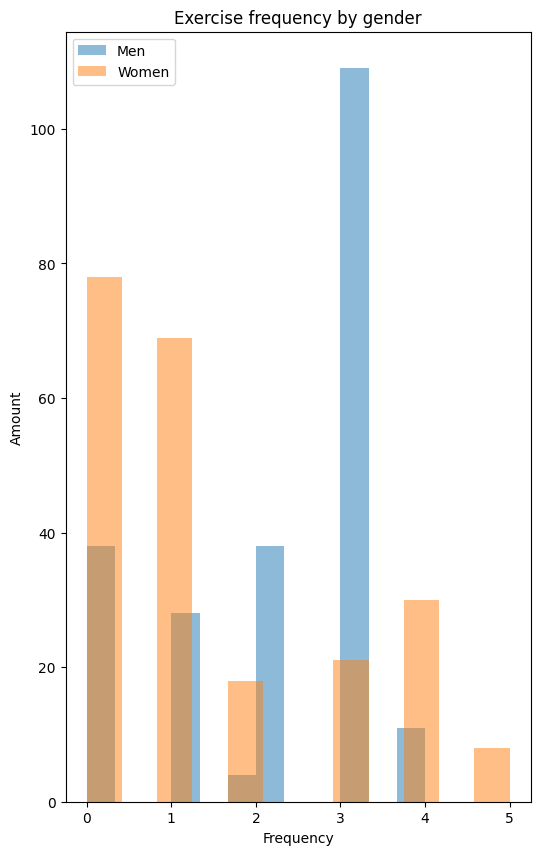

In [45]:
plt.figure(figsize=(6, 10))
plt.hist(men["exercise_frequency"], bins, alpha=0.5, label="Men")
plt.hist(women["exercise_frequency"], bins, alpha=0.5, label="Women")
plt.legend(loc="upper left")
plt.title("Exercise frequency by gender")
plt.ylabel("Amount")
plt.xlabel("Frequency")
plt.show()

__Correlation:__

In [48]:
np.round(st.pearsonr(women["age"], women["sleep_duration"])[0], 2)

np.float64(-0.09)

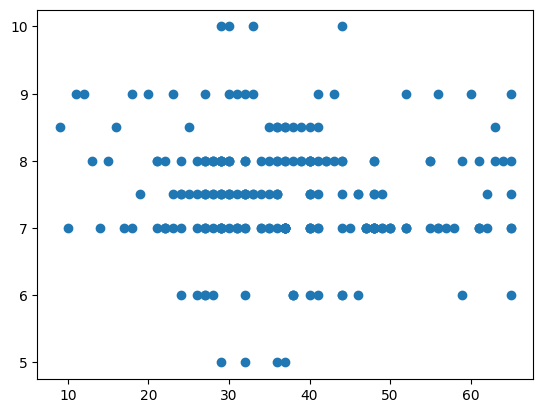

In [49]:
plt.scatter(women["age"], women["sleep_duration"])
plt.show()

In [50]:
x = np.array(women["age"])
y = np.array(women["sleep_duration"])

In [51]:
slope, intercept = np.polyfit(x, y, 1)

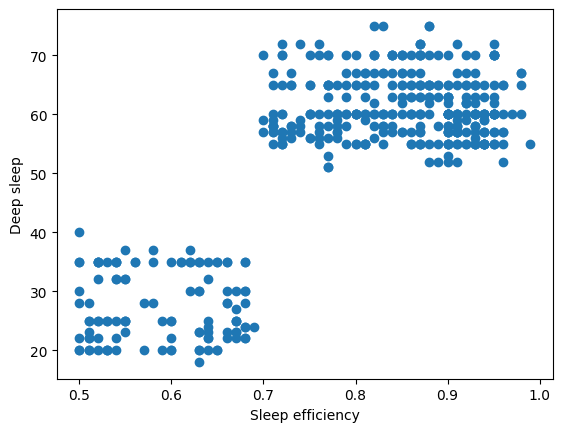

In [56]:
plt.scatter(df["sleep_efficiency"], df["deep_sleep_percentage"])
plt.xlabel("Sleep efficiency")
plt.ylabel("Deep sleep")
plt.show()

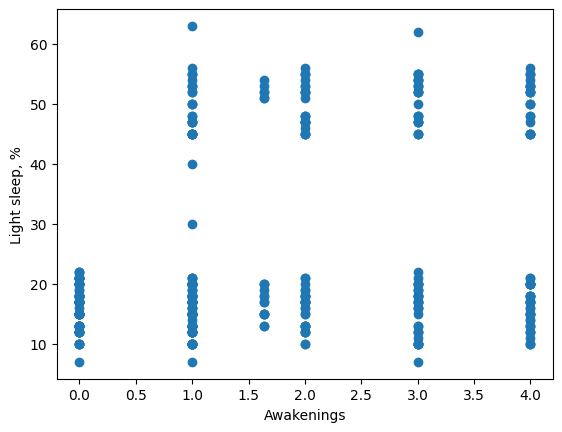

In [59]:
plt.scatter(df["awakenings"], df["light_sleep_percentage"])
plt.xlabel("Awakenings")
plt.ylabel("Light sleep, %")
plt.show()